# Gas ATB 2024 — Envelope multipliers (moderate × multiplier)

This notebook:
1) Loads **advanced / moderate / conservative** CSVs from your raw GitHub URLs  
2) Computes least-squares multipliers mapping `moderate → advanced` and `moderate → conservative` for each metric  
3) Plots an envelope that **starts at START_YEAR**  
4) Works for **multiple technologies** in the same file (e.g., `Gas-CC`, `Gas-CT`)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---------------------------
# CONFIG
# ---------------------------
FILE_URLS = {
    "advanced": "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/gas_ATB_2024_advanced.csv",
    "moderate": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/gas_ATB_2024_moderate.csv",
    "conservative": "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/gas_ATB_2024_conservative.csv",
}

# Technologies (values in column `i`) to process.
# Leave as None to auto-detect all unique values found in the moderate file.
TECH_LIST = None  # e.g., ["Gas-CC", "Gas-CT"]

METRICS = ["capcost", "fom", "vom", "heatrate"]

START_YEAR = 2025

SAVE_CSV = True
OUT_CSV = "gas_envelope_multipliers.csv"

In [3]:
def load_from_urls(urls: dict) -> pd.DataFrame:
    dfs = []
    for scen, url in urls.items():
        df = pd.read_csv(url)
        df["scenario"] = scen
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)

    out["t"] = pd.to_numeric(out["t"], errors="coerce")
    out = out.dropna(subset=["t"]).copy()
    out["t"] = out["t"].astype(int)

    return out.sort_values(["scenario", "i", "t"]).reset_index(drop=True)

df = load_from_urls(FILE_URLS)
df.head()

,i,t,capcost,fom,vom,heatrate,scenario
0,Gas-CC,2010,1141.254325,31.249993,1.991758,6.537500,advanced
1,Gas-CC,2011,1136.675573,31.249993,1.991758,6.518111,advanced
2,Gas-CC,2012,1132.096819,31.249993,1.991758,6.498722,advanced
3,Gas-CC,2013,1127.518066,31.249993,1.991758,6.479333,advanced
4,Gas-CC,2014,1122.939312,31.249993,1.991758,6.459944,advanced


In [4]:
# Decide which techs to run
if TECH_LIST is None:
    TECH_LIST = sorted(df.loc[df["scenario"] == "moderate", "i"].dropna().unique().tolist())

print("TECH_LIST:", TECH_LIST)

TECH_LIST: ['Gas-CC', 'Gas-CT']


In [5]:
def fit_multiplier_ls(moderate: pd.Series, target: pd.Series) -> float:
    m = moderate.values.astype(float)
    y = target.values.astype(float)
    denom = float(np.dot(m, m))
    if denom == 0:
        return np.nan
    return float(np.dot(m, y) / denom)

def envelope_multipliers(df: pd.DataFrame, tech: str, metric: str, start_year: int = 2025) -> dict:
    sub = df[df["i"] == tech].copy()
    piv = (sub[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    for s in ["moderate", "advanced", "conservative"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for tech='{tech}', metric='{metric}'. Found: {list(piv.columns)}")

    window = piv.loc[piv.index >= start_year].dropna(subset=["moderate", "advanced", "conservative"], how="any")
    if len(window) < 2:
        raise ValueError(f"Not enough overlapping years >= {start_year} for tech='{tech}', metric='{metric}'.")

    M = window["moderate"]
    mA = fit_multiplier_ls(M, window["advanced"])
    mC = fit_multiplier_ls(M, window["conservative"])

    low_mult = float(np.nanmin([mA, mC]))
    high_mult = float(np.nanmax([mA, mC]))
    low_ref = "advanced" if mA <= mC else "conservative"
    high_ref = "advanced" if mA >= mC else "conservative"

    return {
        "tech": tech,
        "metric": metric,
        "mA": mA,
        "mC": mC,
        "low_mult": low_mult,
        "high_mult": high_mult,
        "low_ref": low_ref,
        "high_ref": high_ref,
        "n_years_fit": int(len(window)),
        "fit_year_min": int(window.index.min()),
        "fit_year_max": int(window.index.max()),
    }

def plot_with_envelope(df: pd.DataFrame, tech: str, metric: str, start_year: int = 2025):
    info = envelope_multipliers(df, tech, metric, start_year=start_year)

    sub = df[df["i"] == tech].copy()
    piv = (sub[["t", "scenario", metric]]
           .dropna(subset=["t", metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    years = piv.index
    M_all = piv["moderate"]
    env_low = M_all * info["low_mult"]
    env_high = M_all * info["high_mult"]

    # envelope starts at start_year
    mask = years >= start_year
    yrs_env = years[mask]

    plt.figure(figsize=(10, 5))
    plt.fill_between(
        yrs_env,
        env_low.loc[yrs_env].values,
        env_high.loc[yrs_env].values,
        alpha=0.12,
        label=f"Envelope (≥ {start_year})"
    )

    plt.plot(years, piv["moderate"].values, linewidth=2.2, label="Moderate")
    plt.plot(years, piv["advanced"].values, linewidth=2.2, label="Advanced")
    plt.plot(years, piv["conservative"].values, linewidth=2.2, label="Conservative")

    plt.plot(yrs_env, env_low.loc[yrs_env].values, "--",
             label=f"Low: moderate × {info['low_mult']:.4g} ({info['low_ref']} fit)")
    plt.plot(yrs_env, env_high.loc[yrs_env].values, "--",
             label=f"High: moderate × {info['high_mult']:.4g} ({info['high_ref']} fit)")

    plt.axvline(start_year, linewidth=1)
    plt.title(f"{metric} ({tech}): LS envelope using years ≥ {start_year}")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return info

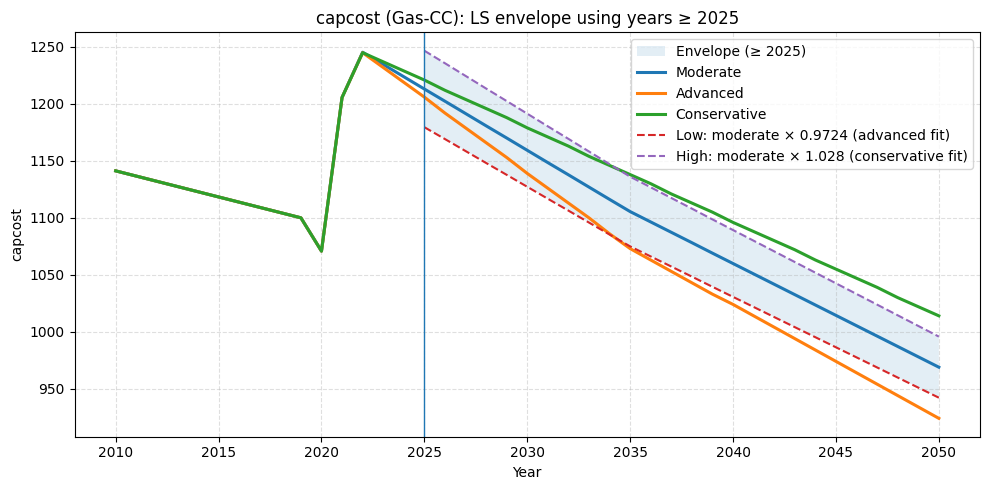

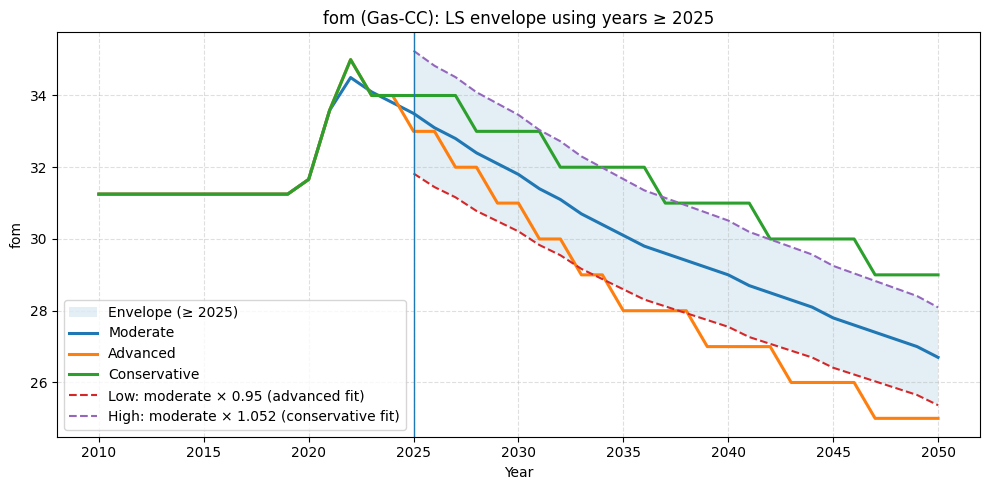

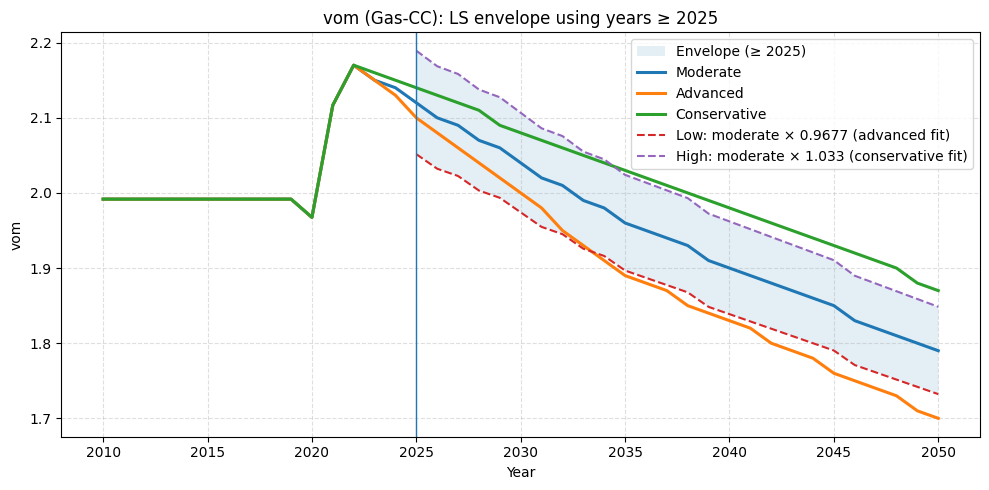

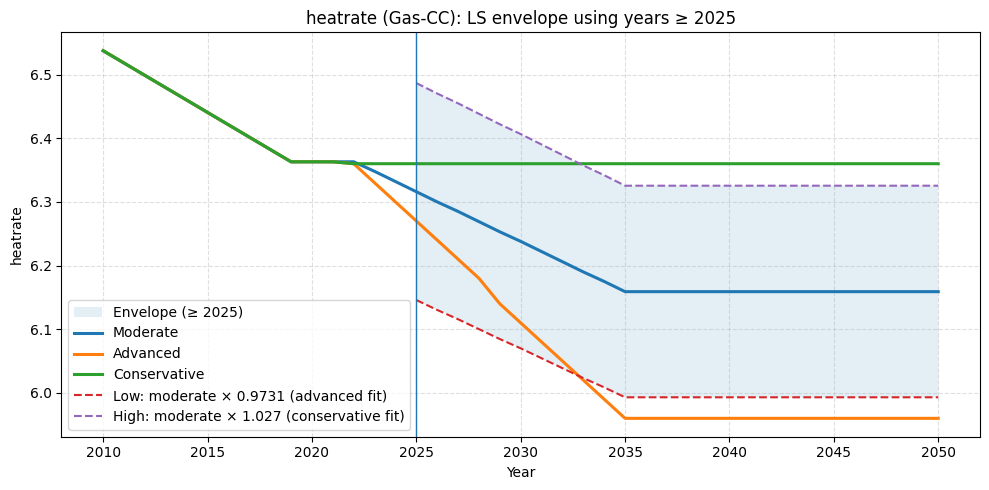

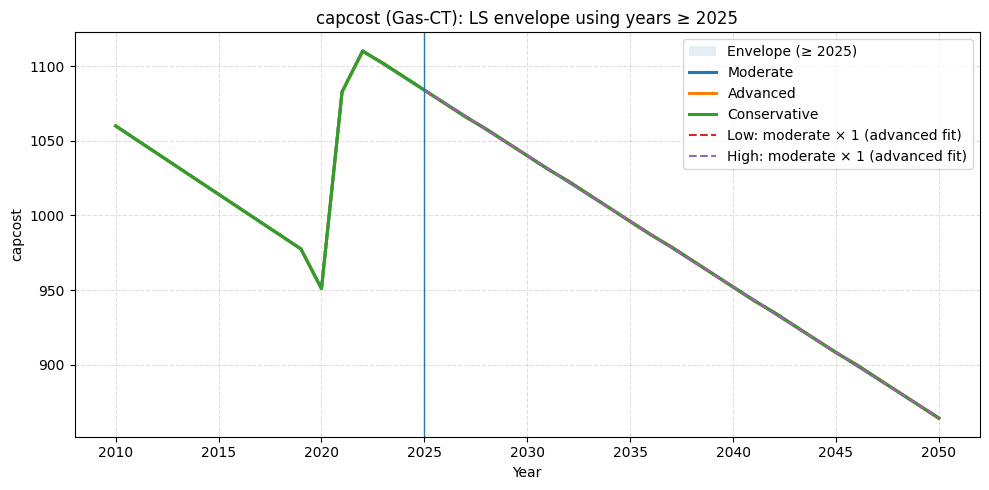

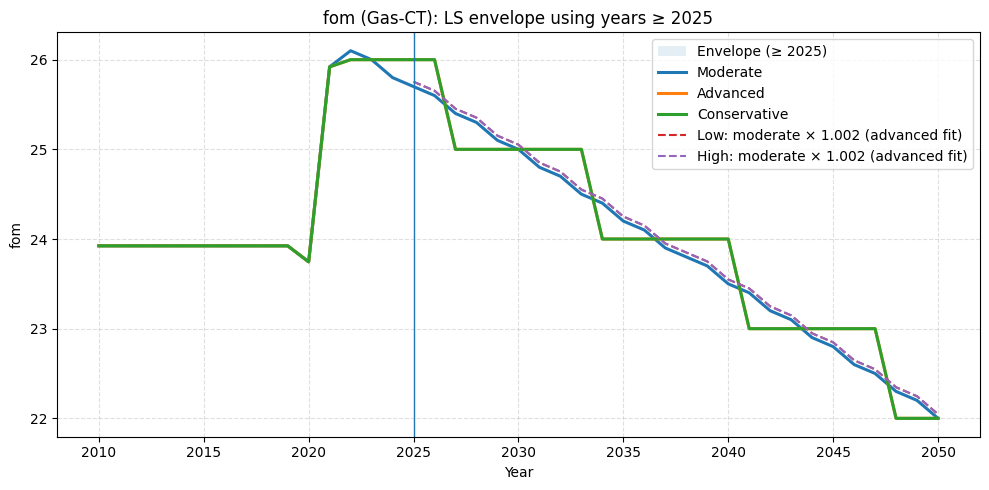

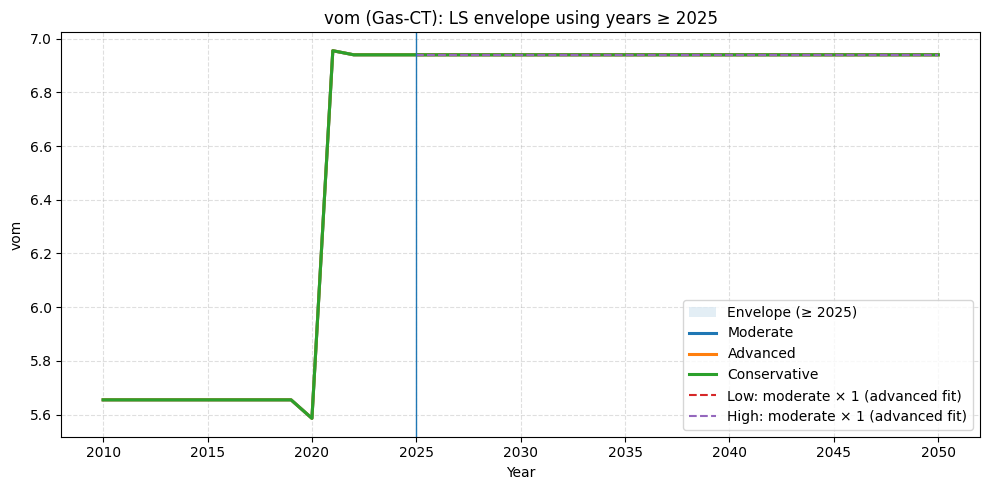

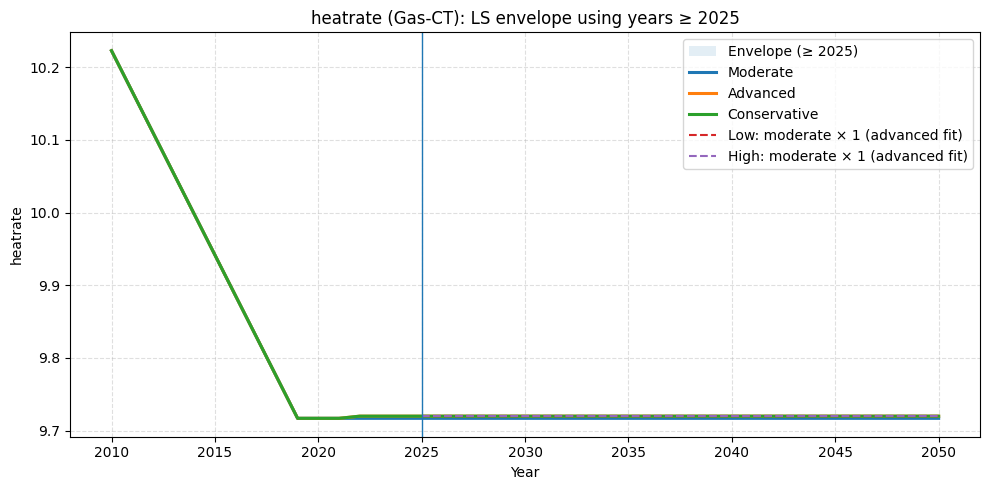

,tech,metric,mA,mC,low_mult,high_mult,low_ref,high_ref,n_years_fit,fit_year_min,fit_year_max
0,Gas-CC,capcost,0.972366,1.027729,0.972366,1.027729,advanced,conservative,26,2025,2050
1,Gas-CC,fom,0.950042,1.052183,0.950042,1.052183,advanced,conservative,26,2025,2050
2,Gas-CC,vom,0.967719,1.032681,0.967719,1.032681,advanced,conservative,26,2025,2050
3,Gas-CC,heatrate,0.973060,1.027025,0.973060,1.027025,advanced,conservative,26,2025,2050
4,Gas-CT,capcost,1.000030,1.000030,1.000030,1.000030,advanced,advanced,26,2025,2050
5,Gas-CT,fom,1.002088,1.002088,1.002088,1.002088,advanced,advanced,26,2025,2050
6,Gas-CT,vom,1.000000,1.000000,1.000000,1.000000,advanced,advanced,26,2025,2050
7,Gas-CT,heatrate,1.000309,1.000309,1.000309,1.000309,advanced,advanced,26,2025,2050


In [6]:
# Run all techs × metrics, plot, and collect multipliers
results = []
for tech in TECH_LIST:
    for m in METRICS:
        results.append(plot_with_envelope(df, tech, m, start_year=START_YEAR))

res = pd.DataFrame(results)
res

In [7]:
if SAVE_CSV:
    res.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)

Saved: gas_envelope_multipliers.csv


# Task
Modify the sampled CSV generation logic in the notebook to apply the sampled multipliers only to 'Gas-CC' rows where the 't' (year) column is greater than or equal to `START_YEAR` (2025). For years prior to `START_YEAR`, the 'Gas-CC' values should remain unchanged, taking their original 'moderate' scenario values. After modifying the code, re-run the cell to regenerate the `gas_ATB_2024_sample_XXX.csv` files and then verify that the 'Gas-CC' metric values are multiplied by the sampled factors only for years equal to or after 2025, while remaining unchanged for earlier years.

## Modify Sampled CSV Generation Logic

### Subtask:
Adjust the code within the file generation loop to apply the sampled multipliers only to 'Gas-CC' rows where the 't' (year) column is greater than or equal to `START_YEAR` (which is 2025). For years prior to `START_YEAR`, the 'Gas-CC' values should remain unchanged, taking their original 'moderate' scenario values.


**Reasoning**:
To ensure that multipliers are applied only to 'Gas-CC' rows with years greater than or equal to `START_YEAR`, I will modify the sampling loop to create a new mask that incorporates this year condition and use it when applying the multipliers.



In [8]:
from pathlib import Path

# -----------------------------
# 0) Inputs you can change
# -----------------------------
N_SAMPLES =2
SEED = 123
FIT_YEAR_MIN = 2025
FIT_YEAR_MAX = 2050
TECH_TO_SAMPLE = "Gas-CC"
METRICS = ["capcost", "fom", "vom", "heatrate"]

out_dir = Path("gas_ATB_2024_samples")
out_dir.mkdir(parents=True, exist_ok=True)

# Ensure df_mod and bounds are defined (copied from cell c1d720f0)
df_mod = df[df["scenario"] == "moderate"].copy()
gas_cc_multipliers = res[res['tech'] == 'Gas-CC'].copy()

bounds = {}
for _, row in gas_cc_multipliers.iterrows():
    metric = row["metric"]
    low_mult = row["low_mult"]
    high_mult = row["high_mult"]
    bounds[metric] = (low_mult, high_mult)


# -----------------------------
# 3) Sample multipliers ONLY for Gas-CC and ONLY for the 4 metrics
#    Store in list format (list of dicts)
# -----------------------------
rng = np.random.default_rng(SEED)

samples = []
for s in range(N_SAMPLES):
    d = {"sample_id": s}
    for metric in METRICS:
        lo, hi = bounds[metric]
        # uniform sampling inside envelope
        d[f"{metric}_mult"] = float(rng.uniform(lo, hi))
    samples.append(d)

# list format (what you asked for)
# (optional) show first few
print("\nFirst 5 sampled multiplier sets:")
for row in samples[:5]:
    print(row)

df_samples = pd.DataFrame(samples)
df_samples.to_csv(out_dir / "gas_ATB_2024_multiplier_samples.csv", index=False)

# -----------------------------
# 4) Generate ReEDS-style gas_ATB_2024 CSV for each sample:
#    - Start from MODERATE file as baseline
#    - Multiply ONLY Gas-CC rows by the sampled multipliers
#    - Leave Gas-CT (and anything else) unchanged
# -----------------------------
df_base = df_mod.copy()

# sanity check the tech exists
if TECH_TO_SAMPLE not in set(df_base["i"].unique()):
    raise ValueError(f"'{TECH_TO_SAMPLE}' not found in df_mod['i']. Unique techs: {sorted(df_base['i'].unique())[:20]} ...")

mask_cc = (df_base["i"] == TECH_TO_SAMPLE)

generated_files = []
for _, row in df_samples.iterrows():
    df_out = df_base.copy()

    # NEW: Create a mask for applying multipliers only to Gas-CC rows and for years >= START_YEAR
    mask_apply_mult = mask_cc & (df_out["t"] >= START_YEAR)

    # apply multipliers to Gas-CC only for years >= START_YEAR
    for metric in METRICS:
        mult = row[f"{metric}_mult"]
        df_out.loc[mask_apply_mult, metric] = df_out.loc[mask_apply_mult, metric].astype(float) * float(mult)

    # write file
    sid = int(row["sample_id"])
    fp = out_dir / f"gas_ATB_2024_sample_{sid:03d}.csv"
    df_out.to_csv(fp, index=False, float_format="%.6f")
    generated_files.append(str(fp))

# optional: write a text list of generated CSVs
with open(out_dir / "gas_ATB_2024_generated_file_list.txt", "w") as f:
    f.write("\n".join(generated_files))

print(f"\nDone. Wrote {len(generated_files)} files to: {out_dir.resolve()}")
print(f"Saved multipliers table: {out_dir / 'gas_ATB_2024_multiplier_samples.csv'}")


First 5 sampled multiplier sets:
{'sample_id': 0, 'capcost_mult': 1.0101427030392358, 'fom_mult': 0.9555390382884612, 'vom_mult': 0.9820339400944623, 'heatrate_mult': 0.9830094769803294}
{'sample_id': 1, 'capcost_mult': 0.9821044971604636, 'fom_mult': 1.0329904670072374, 'vom_mult': 1.027701602696271, 'heatrate_mult': 0.9879852331660625}

Done. Wrote 2 files to: /content/gas_ATB_2024_samples
Saved multipliers table: gas_ATB_2024_samples/gas_ATB_2024_multiplier_samples.csv


**Reasoning**:
The previous step modified the code to apply multipliers conditionally. Now, to verify the changes, I will load one of the newly generated sample files and compare the 'Gas-CC' metric values before and after `START_YEAR` (2025) to confirm that multipliers were applied only to years >= 2025.



In [9]:
import pandas as pd

# Load one of the generated sample files
sample_file_path = "gas_ATB_2024_samples/gas_ATB_2024_sample_000.csv"
df_sample = pd.read_csv(sample_file_path)

# Load the original moderate scenario data for comparison
df_moderate = df[df["scenario"] == "moderate"].copy()

# Get the multipliers for the first sample (sample_id=0)
sampled_multipliers = df_samples.loc[df_samples['sample_id'] == 0, ['capcost_mult', 'fom_mult', 'vom_mult', 'heatrate_mult']].iloc[0]

TECH_TO_SAMPLE = "Gas-CC"
START_YEAR = 2025
METRICS = ["capcost", "fom", "vom", "heatrate"]

print(f"Verifying sample file: {sample_file_path}")
print(f"Multipliers for sample 0: {sampled_multipliers.to_dict()}")

for metric in METRICS:
    print(f"\n--- Metric: {metric} ---")
    # Select a Gas-CC row before START_YEAR
    row_before_start = df_sample[(df_sample['i'] == TECH_TO_SAMPLE) & (df_sample['t'] == START_YEAR - 1)]
    original_moderate_before_start = df_moderate[(df_moderate['i'] == TECH_TO_SAMPLE) & (df_moderate['t'] == START_YEAR - 1)]

    if not row_before_start.empty and not original_moderate_before_start.empty:
        val_sampled_before = row_before_start[metric].values[0]
        val_moderate_before = original_moderate_before_start[metric].values[0]
        print(f"Year {START_YEAR - 1} ({TECH_TO_SAMPLE}, {metric}):")
        print(f"  Sampled: {val_sampled_before:.6f}")
        print(f"  Moderate (original): {val_moderate_before:.6f}")
        if abs(val_sampled_before - val_moderate_before) < 1e-6:
            print("  -> Values are unchanged (correct).")
        else:
            print("  -> ERROR: Values changed before START_YEAR (incorrect).")
    else:
        print(f"No data for year {START_YEAR - 1} for {TECH_TO_SAMPLE}, {metric}")

    # Select a Gas-CC row at or after START_YEAR
    row_at_start = df_sample[(df_sample['i'] == TECH_TO_SAMPLE) & (df_sample['t'] == START_YEAR)]
    original_moderate_at_start = df_moderate[(df_moderate['i'] == TECH_TO_SAMPLE) & (df_moderate['t'] == START_YEAR)]

    if not row_at_start.empty and not original_moderate_at_start.empty:
        val_sampled_at = row_at_start[metric].values[0]
        val_moderate_at = original_moderate_at_start[metric].values[0]
        expected_val_at = val_moderate_at * sampled_multipliers[f'{metric}_mult']

        print(f"Year {START_YEAR} ({TECH_TO_SAMPLE}, {metric}):")
        print(f"  Sampled: {val_sampled_at:.6f}")
        print(f"  Moderate (original): {val_moderate_at:.6f}")
        print(f"  Expected (Moderate * Mult): {expected_val_at:.6f}")
        if abs(val_sampled_at - expected_val_at) < 1e-6:
            print("  -> Values are multiplied correctly (correct).")
        else:
            print(f"  -> ERROR: Values not multiplied correctly at START_YEAR (incorrect). Difference: {val_sampled_at - expected_val_at:.6f}")
    else:
        print(f"No data for year {START_YEAR} for {TECH_TO_SAMPLE}, {metric}")


Verifying sample file: gas_ATB_2024_samples/gas_ATB_2024_sample_000.csv
Multipliers for sample 0: {'capcost_mult': 1.0101427030392358, 'fom_mult': 0.9555390382884612, 'vom_mult': 0.9820339400944623, 'heatrate_mult': 0.9830094769803294}

--- Metric: capcost ---
Year 2024 (Gas-CC, capcost):
  Sampled: 1223.900000
  Moderate (original): 1223.900000
  -> Values are unchanged (correct).
Year 2025 (Gas-CC, capcost):
  Sampled: 1225.404113
  Moderate (original): 1213.100000
  Expected (Moderate * Mult): 1225.404113
  -> Values are multiplied correctly (correct).

--- Metric: fom ---
Year 2024 (Gas-CC, fom):
  Sampled: 33.800000
  Moderate (original): 33.800000
  -> Values are unchanged (correct).
Year 2025 (Gas-CC, fom):
  Sampled: 32.010558
  Moderate (original): 33.500000
  Expected (Moderate * Mult): 32.010558
  -> Values are multiplied correctly (correct).

--- Metric: vom ---
Year 2024 (Gas-CC, vom):
  Sampled: 2.140000
  Moderate (original): 2.140000
  -> Values are unchanged (correct).

In [10]:
from IPython.display import Markdown, display

# Units of the underlying parameters (multipliers themselves are unitless)
metric_units = {
    "capcost": r"\$/MW",
    "fom": r"\$/MW-yr",
    "vom": r"\$/MWh",
    "heatrate": r"MMBtu/MWh",
}

latex_rows = []
for metric in METRICS:  # keeps your preferred order
    low_mult, high_mult = bounds[metric]
    unit = metric_units.get(metric, "unitless")

    parameter = rf"Gas-CC -- {metric}"
    latex_rows.append(
        rf"{parameter} & {high_mult:.4f} & {low_mult:.4f} & {unit} (multiplier) \\"
    )

full_latex_table = rf"""
\begin{{table}}[h!]
\centering
\caption{{Sampled Multiplier Bounds and Parameter Units for Gas-CC ATB 2024}}
\label{{tab:gas_cc_metric_bounds_units}}
\begin{{tabular}}{{{'l' * (4)}}}
\toprule
Parameter & High Multiplier & Low Multiplier & Units \\
\midrule
{'\n'.join(latex_rows)}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

display(Markdown(full_latex_table))


\begin{table}[h!]
\centering
\caption{Sampled Multiplier Bounds and Parameter Units for Gas-CC ATB 2024}
\label{tab:gas_cc_metric_bounds_units}
\begin{tabular}{llll}
\toprule
Parameter & High Multiplier & Low Multiplier & Units \\
\midrule
Gas-CC -- capcost & 1.0277 & 0.9724 & \$/MW (multiplier) \\
Gas-CC -- fom & 1.0522 & 0.9500 & \$/MW-yr (multiplier) \\
Gas-CC -- vom & 1.0327 & 0.9677 & \$/MWh (multiplier) \\
Gas-CC -- heatrate & 1.0270 & 0.9731 & MMBtu/MWh (multiplier) \\
\bottomrule
\end{tabular}
\end{table}


In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# Gas ATB 2024 — generate ONE ReEDS-format CSV per Morris row
#   - Uses your Morris design + factor map from GitHub
#   - Applies multipliers ONLY for years > 2025 (i.e., 2026+)
#   - ONLY changes Gas-CC for: capcost, fom, vom, heatrate
#   - Preserves EXACT GitHub-style columns/order as in the base moderate
# ============================================================

# -----------------------
# (0) CONFIG
# -----------------------
APPLY_AFTER_YEAR = 2025  # apply for t > 2025 (2026+)

TECH_TO_SAMPLE = "Gas-CC"
METRICS = ["capcost", "fom", "vom", "heatrate"]

MORRIS_DESIGN_URL = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_design_r5_p6.csv#/"
FACTOR_MAP_URL    = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/morris_factor_map.csv#/"

OUT_DIR = Path("gas_ATB_2024_morris_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_MANIFEST = True
MANIFEST_CSV = OUT_DIR / "gas_ATB_2024_morris_manifest.csv"

# -----------------------
# (1) LOAD MORRIS FILES
# -----------------------
design = pd.read_csv(MORRIS_DESIGN_URL)
factor_map = pd.read_csv(FACTOR_MAP_URL)

# -----------------------
# (2) BUILD / LOAD BASE MODERATE TABLE (GitHub format)
#     You already have these in your notebook from earlier cells:
#       df_mod = df[df["scenario"] == "moderate"].copy()
#
#     If your variable name differs, map it below.
# -----------------------
if "df" not in globals():
    raise NameError("I expected a dataframe named `df` containing gas ATB data with a 'scenario' column.")

df_mod = df[df["scenario"] == "moderate"].copy()

# Validate base columns exist (we keep EXACT column set/order from df_mod)
required = ["i", "t"] + METRICS
missing = [c for c in required if c not in df_mod.columns]
if missing:
    raise ValueError(f"df_mod is missing required columns: {missing}. Found: {list(df_mod.columns)}")

df_mod = df_mod.copy()
df_mod["t"] = pd.to_numeric(df_mod["t"], errors="raise").astype(int)

# Keep exact base column order to avoid ReEDS errors:
BASE_COL_ORDER = list(df_mod.columns)

# sanity check tech exists
if TECH_TO_SAMPLE not in set(df_mod["i"].unique()):
    raise ValueError(
        f"'{TECH_TO_SAMPLE}' not found in df_mod['i']. "
        f"Unique techs (first 30): {sorted(df_mod['i'].unique())[:30]}"
    )

# -----------------------
# (3) HELPERS
# -----------------------
def resolve_design_column(design_df: pd.DataFrame, factor_map_df: pd.DataFrame, cls: str, metric: str) -> str | None:
    """
    Finds the column in the Morris design corresponding to (cls, metric).
    Supports:
      - direct design columns like 'Gas-CC__capcost'
      - design columns named by factor IDs that map via factor_map['parameter']
    """
    cols_lower = {c.lower(): c for c in design_df.columns}

    # direct patterns
    candidates = [
        f"{cls}__{metric}",
        f"{cls}--{metric}",
        f"{cls} -- {metric}",
        f"{cls}_{metric}",
        f"{cls} {metric}",
    ]
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    # factor_map-based patterns
    for param_col in ["parameter", "Parameter", "name", "Name", "desc", "description"]:
        if param_col in factor_map_df.columns:
            mask = (
                factor_map_df[param_col].astype(str).str.contains(cls, case=False, na=False)
                & factor_map_df[param_col].astype(str).str.contains(metric, case=False, na=False)
            )
            hits = factor_map_df.loc[mask]
            if len(hits) >= 1:
                for factor_col in ["factor", "Factor", "id", "ID"]:
                    if factor_col in factor_map_df.columns:
                        f = str(hits.iloc[0][factor_col])
                        if f.lower() in cols_lower:
                            return cols_lower[f.lower()]
                        if f in design_df.columns:
                            return f
            break

    return None

def apply_gascc_multipliers_only_after_2025(base_df: pd.DataFrame, mults: dict, apply_after_year: int = 2025) -> pd.DataFrame:
    """
    mults: {metric: multiplier}
    Applies only for Gas-CC rows and for years > apply_after_year (i.e., 2026+)
    """
    out = base_df.copy()
    mask_apply = (out["i"] == TECH_TO_SAMPLE) & (out["t"].astype(int) > int(apply_after_year))

    for metric, mult in mults.items():
        if metric not in out.columns:
            raise ValueError(f"Metric '{metric}' not found in base df columns.")
        if pd.isna(mult):
            mult = 1.0
        out.loc[mask_apply, metric] = out.loc[mask_apply, metric].astype(float) * float(mult)

    # enforce exact base ordering
    out = out[BASE_COL_ORDER]
    return out

# -----------------------
# (4) RESOLVE MORRIS DESIGN COLUMNS FOR GAS-CC FACTORS
# -----------------------
col_lookup = {}
missing_factors = []
for metric in METRICS:
    dc = resolve_design_column(design, factor_map, TECH_TO_SAMPLE, metric)
    if dc is None:
        missing_factors.append(f"{TECH_TO_SAMPLE}::{metric}")
    else:
        col_lookup[metric] = dc

if missing_factors:
    raise ValueError(
        "Could not find Morris design columns for these Gas-CC factors:\n"
        f"  {missing_factors}\n\n"
        "Fix by renaming your Morris design columns to one of these patterns:\n"
        "  Gas-CC__capcost, Gas-CC__fom, Gas-CC__vom, Gas-CC__heatrate\n\n"
        f"Design columns found (first 30): {list(design.columns)[:30]}"
    )

print("Resolved Morris design columns for Gas-CC factors:")
for k, v in col_lookup.items():
    print(f"  {k} -> {v}")

# -----------------------
# (5) GENERATE ONE CSV PER MORRIS ROW
# -----------------------
manifest = []

for ridx, row in design.reset_index(drop=True).iterrows():
    mults = {}
    for metric in METRICS:
        dcol = col_lookup[metric]
        mults[metric] = float(row[dcol]) if not pd.isna(row[dcol]) else 1.0

    df_out = apply_gascc_multipliers_only_after_2025(
        base_df=df_mod,
        mults=mults,
        apply_after_year=APPLY_AFTER_YEAR
    )

    fname = f"gas_ATB_2024_morris_{ridx:03d}.csv"
    fpath = OUT_DIR / fname
    df_out.to_csv(fpath, index=False, float_format="%.6f")

    rec = {
        "morris_row": ridx,
        "file": fname,
        "apply_after_year": APPLY_AFTER_YEAR,
    }
    for metric in METRICS:
        rec[f"{TECH_TO_SAMPLE}__{metric}_mult"] = mults[metric]
    manifest.append(rec)

manifest_df = pd.DataFrame(manifest)
if SAVE_MANIFEST:
    manifest_df.to_csv(MANIFEST_CSV, index=False)

print(f"\nDone. Wrote {len(manifest_df)} files to: {OUT_DIR.resolve()}")
print(f"Saved manifest: {MANIFEST_CSV}")
print("\nPreview first output:")
display(pd.read_csv(OUT_DIR / "gas_ATB_2024_morris_000.csv").head(20))

# -----------------------
# (6) OPTIONAL: VALIDATION (PREVENTS REEDS ERRORS)
# -----------------------
def validate_exact_match_to_base(path_csv: Path, base_cols: list[str]) -> None:
    tmp = pd.read_csv(path_csv)
    if list(tmp.columns) != base_cols:
        raise ValueError(
            f"Column mismatch in {path_csv.name}\n"
            f"Expected: {base_cols}\n"
            f"Found:    {list(tmp.columns)}"
        )

validate_exact_match_to_base(OUT_DIR / "gas_ATB_2024_morris_000.csv", BASE_COL_ORDER)
validate_exact_match_to_base(OUT_DIR / f"gas_ATB_2024_morris_{len(manifest_df)-1:03d}.csv", BASE_COL_ORDER)
print("\nValidation passed (columns/order match base moderate exactly).")


Resolved Morris design columns for Gas-CC factors:
  capcost -> gas_cc_capcost
  fom -> gas_cc_fom
  vom -> gas_cc_vom
  heatrate -> gas_cc_heatrate

Done. Wrote 200 files to: /content/gas_ATB_2024_morris_outputs
Saved manifest: gas_ATB_2024_morris_outputs/gas_ATB_2024_morris_manifest.csv

Preview first output:


,i,t,capcost,fom,vom,heatrate,scenario
0,Gas-CC,2010,1141.254325,31.249993,1.991758,6.537500,moderate
1,Gas-CC,2011,1136.675573,31.249993,1.991758,6.518111,moderate
2,Gas-CC,2012,1132.096819,31.249993,1.991758,6.498722,moderate
3,Gas-CC,2013,1127.518066,31.249993,1.991758,6.479333,moderate
4,Gas-CC,2014,1122.939312,31.249993,1.991758,6.459944,moderate
5,Gas-CC,2015,1118.360558,31.249993,1.991758,6.440556,moderate
6,Gas-CC,2016,1113.781805,31.249993,1.991758,6.421167,moderate
7,Gas-CC,2017,1109.203051,31.249993,1.991758,6.401778,moderate
8,Gas-CC,2018,1104.624297,31.249993,1.991758,6.382389,moderate
9,Gas-CC,2019,1100.045544,31.249993,1.991758,6.363000,moderate



Validation passed (columns/order match base moderate exactly).


In [12]:
from pathlib import Path
import shutil

OUT_DIR = Path("gas_ATB_2024_morris_outputs")  # <- must match your script
zip_name = "gas_ATB_2024_morris_outputs"

# create gas_ccs_ATB_2024_morris_outputs.zip
shutil.make_archive(zip_name, "zip", OUT_DIR)

print("Created:", f"{zip_name}.zip")

Created: gas_ATB_2024_morris_outputs.zip
